# 📝 Análise de Sessões Prévias

À medida que times se preparam para a corrida no domingo, eles se utilizam dos dados coletados durante o final de semana para tentar elaborar estratégias e planos. Vamos analisar esses dados, com atenção especial para o nosso time...

Nota: para simplificar a análise, vamos levar em consideração que a temperatura e tempo foram iguais em todas as sessões.

Nota 2: Para evitar que a plateia descubra qual foi o GP, os resultados obtidos na corrida de sprint estarão ocultos. Mas considere que foram bons, e similares aos obtidos na qualificatória.

## 📊 Como avaliar a performance?

A maioria dos times do grid não estão no topo. Eles geralmente disputam por posições intermediárias. Como esses times avaliam a performance deles quando não são capazes de vencerem os times maiores?

Ademais, sessões de prática não tem posições. Então como avaliamos performance quando posições não são levadas em consideração?

Na maioria das vezes, times avaliam o ritmo deles, isto é, o tempo de volta. Atingir bons tempos de volta é o fundamental para vencer uma corrida, por mais que não sejam tudo. Ao longo deste final de semana em específico, a correlação entre tempos de volta e posição na sessão de sprint foi de 0.8.

Para que isso seja feito, será utilizado o método `pick_quicklaps` do FastF1, uma vez que esse método filtra apenas voltas dentro do intervalo de 107% da volta mais rápida para a sessão em específico, excluindo voltas deliberadamente lentas da maioria das análises.

## ⚙️ Configurações de ambiente

In [ ]:
import os

import fastf1 as ff1
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from fastf1 import plotting
from fastf1.logger import set_log_level

from plots.anonymize import ANON_DRIVER_MAPPING, ANON_TEAM_MAPPING, ANON_TEAM_PALETTE
from plots.correlation import plot_scatter
from plots.laps import plot_laptime_correlation_heatmap, plot_team_vs_grid_tyre_wear
from plots.tyres import (
    plot_average_lap_time_by_tyre_wear,
    plot_laptime_distribution_by_team_with_tyre_life,
    plot_tyre_decay_scatter_plot,
)
from processing.laps import get_tyre_life_stats
from tests.comparisons import compare_team_series_to_overall_series
from tests.distribution import ks_test, mann_whitney_u_test
from tests.normality import plot_normality_visual_inspection, shapiro_wilk_test

load_dotenv()

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")
np.random.seed(123)  # noqa: NPY002

TEAM = os.getenv("TEAM")
EVENT_YEAR = int(os.getenv("EVENT_YEAR"))
ROUND = int(os.getenv("ROUND"))

%matplotlib widget

## 📚 Agregando e limpando dados

### 🗂️ Agregando dados de voltas de todas as sessões antes da corrida durante o final de semana

Os dados de todas as sessões anteriores à corrida serão agregados em um único DataFrame e utilizados para análises.

In [2]:
fp1 = ff1.get_session(EVENT_YEAR, ROUND, "FP1")
sq = ff1.get_session(EVENT_YEAR, ROUND, "SQ")
sprint = ff1.get_session(EVENT_YEAR, ROUND, "S")
quali = ff1.get_session(EVENT_YEAR, ROUND, "Q")
fp1.load(telemetry=False, weather=False)
sq.load(telemetry=False, weather=False)
sprint.load(telemetry=False, weather=False)
quali.load(telemetry=False, weather=False)

In [3]:
fp1_push_laps = fp1.laps.pick_quicklaps()
sq_push_laps = sq.laps.pick_quicklaps()
sprint_push_laps = sprint.laps.pick_quicklaps()
quali_push_laps = quali.laps.pick_quicklaps()

In [4]:
all_laps = pd.concat(
    [
        fp1_push_laps.assign(Session="FP1"),
        sq_push_laps.assign(Session="SQ"),
        sprint_push_laps.assign(Session="Sprint"),
        quali_push_laps.assign(Session="Quali"),
    ],
    ignore_index=True,
)

### ✨ Limpeza de dados e feature engineering

In [5]:
all_laps = all_laps[~all_laps["Deleted"]]  # Removing deleted laps, they are invalid

Convertendo o tempo de volta para segundos para facilitar cálculos.

In [6]:
all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()

C:\Users\Vitor\AppData\Local\Temp\ipykernel_26544\2692686783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_laps["LapTime_s"] = all_laps["LapTime"].dt.total_seconds()


In [7]:
# Removing unused featured for easier and lighter calculations
DROP_FEATURES = [
    "Deleted",
    "DeletedReason",
    "FastF1Generated",
    "LapStartTime",
    "LapStartDate",
    "Sector1SessionTime",
    "Sector2SessionTime",
    "Sector3SessionTime",
    "IsPersonalBest",
    "IsAccurate",
    "SpeedFL",
]
all_laps = all_laps.drop(columns=DROP_FEATURES)

Convertendo dados categóricos para inteiros para cálculo de correlações.

In [8]:
session_dummies = pd.get_dummies(all_laps.Session, prefix="Session", dtype=int)
all_laps = pd.concat([all_laps, session_dummies], axis=1)

In [9]:
all_laps["HiddenTeam"] = all_laps["Team"].map(lambda t: ANON_TEAM_MAPPING.get(t, t))

In [10]:
all_laps["HiddenDriver"] = all_laps["Driver"].map(
    lambda d: ANON_DRIVER_MAPPING.get(d, d),
)

### 🏷️ Separando dados por composto de pneu

In [12]:
soft = all_laps.pick_compounds("SOFT")
medium = all_laps.pick_compounds("MEDIUM")
hard = all_laps.pick_compounds("HARD")

## 🕰️ Analisando tendências e distribuição de tempos de volta

### ⏳ Analisando tempo de volta geral

Primeiramente, vamos observar quanto tempo uma volta geralmente toma, levando em consdideração todo o grid, independete da sessão e de composto de pneu.

In [13]:
print(
    f"Durante este final de semana, uma volta média levou {all_laps.LapTime_s.mean():.3f} "
    f" +/- {all_laps.LapTime_s.std():.3f} segundos",
)

Durante este final de semana, uma volta média levou 84.157  +/- 2.182 segundos


Dessa forma, meros segundos a cada volta separam vencedores e perdedores.

Depois disso, checamos os tempos de volta para distribuição normal, para enteder quais ferramentas estatísticas poderiam ser utilizadas.

Test statistic 0.9068
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


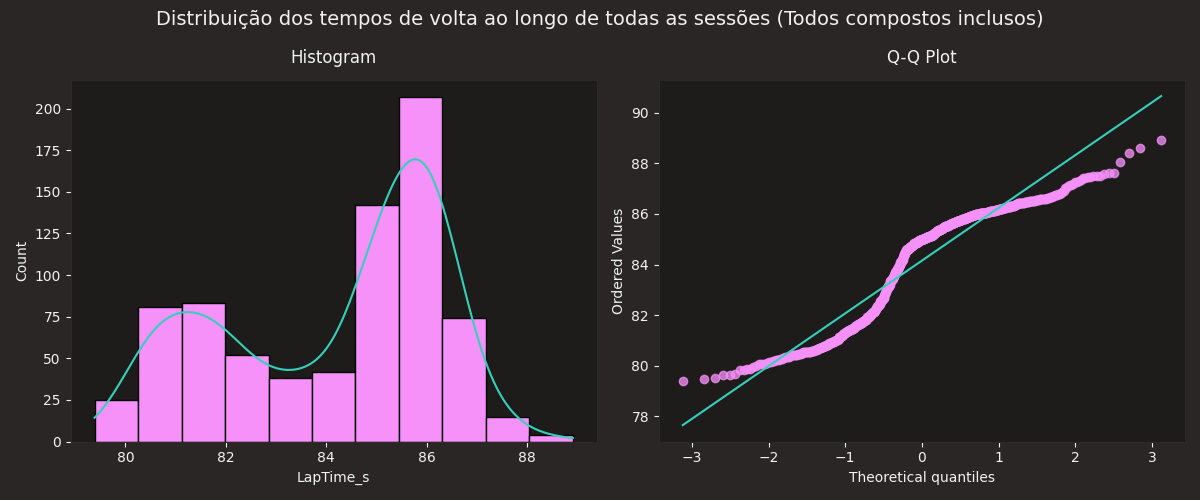

In [14]:
shapiro_wilk_test(all_laps.LapTime_s, language="pt")
plot_normality_visual_inspection(
    all_laps.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Todos compostos inclusos)",
)

É possível visualizar que os dados não são normalmente distribuídos. Teremos de usar testes não paramétricos ao analisar tempos de volta neste recorte de dados.

Vamos checar se os resultados são diferentes ao separar por compostos de pneu:

Test statistic 0.8181
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


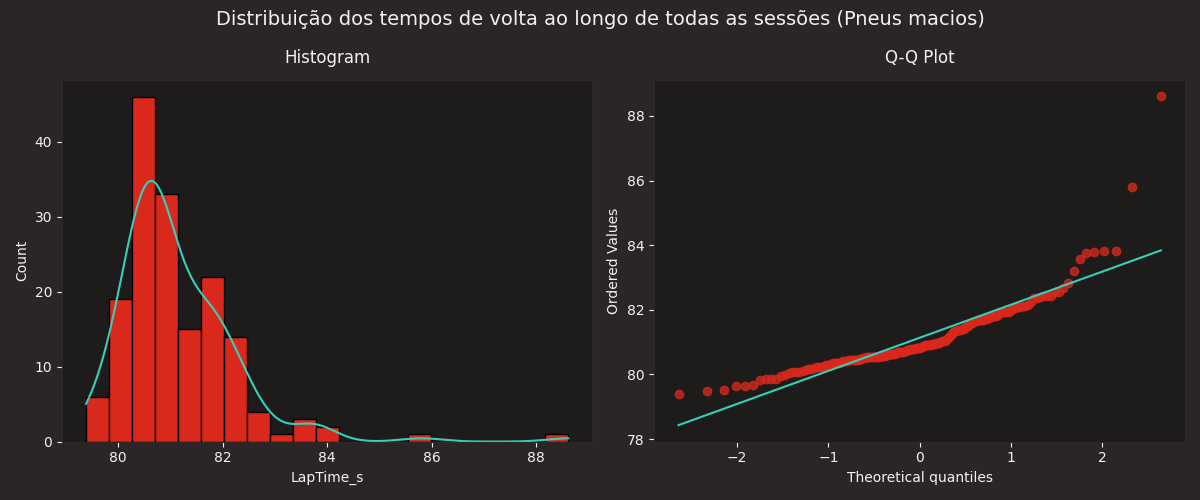

In [15]:
shapiro_wilk_test(soft.LapTime_s, language="pt")
plot_normality_visual_inspection(
    soft.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Pneus macios)",
    color=plotting.get_compound_color("soft", session=quali),
)

A alta concentração na área esquerda do gráfico pode ser explicada pelo fato de que compostos macios são projetados para trazer os carros o mais próximo possível aos seus limites de velocidade. Esse composto é usado para stints curtos, como voltas qualificatórias. Em breve, nos aprofundaremos mais nesse composto.

Test statistic 0.8705
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


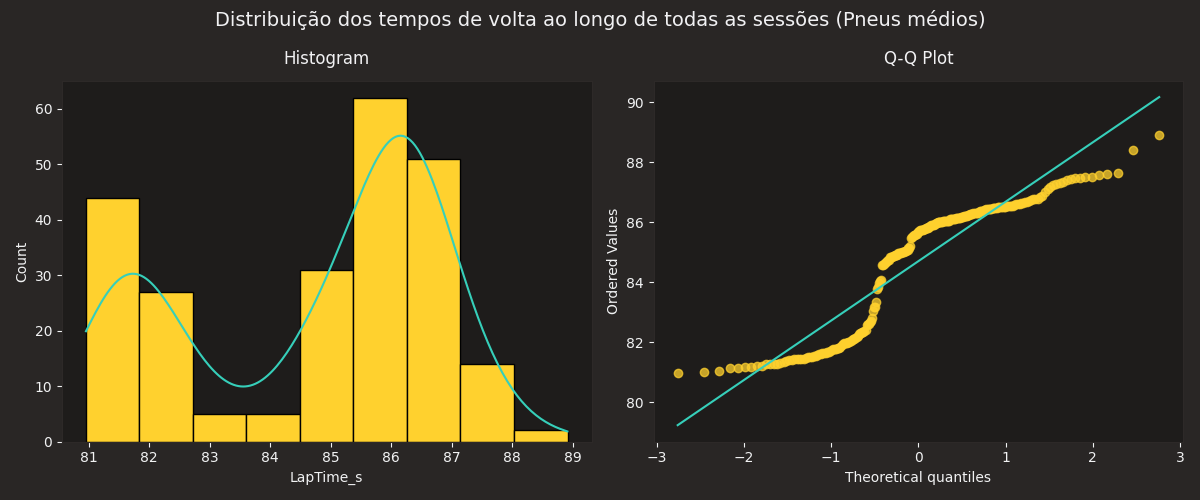

In [16]:
shapiro_wilk_test(medium.LapTime_s, language="pt")
plot_normality_visual_inspection(
    medium.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Pneus médios)",
    color=plotting.get_compound_color("medium", session=quali),
)

Curiosamente, a distribuição para os pneus médios possui duas concentrações diferentes. Em breve, nos aprofundaremos mais nessa distribuição.

Test statistic 0.9458
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


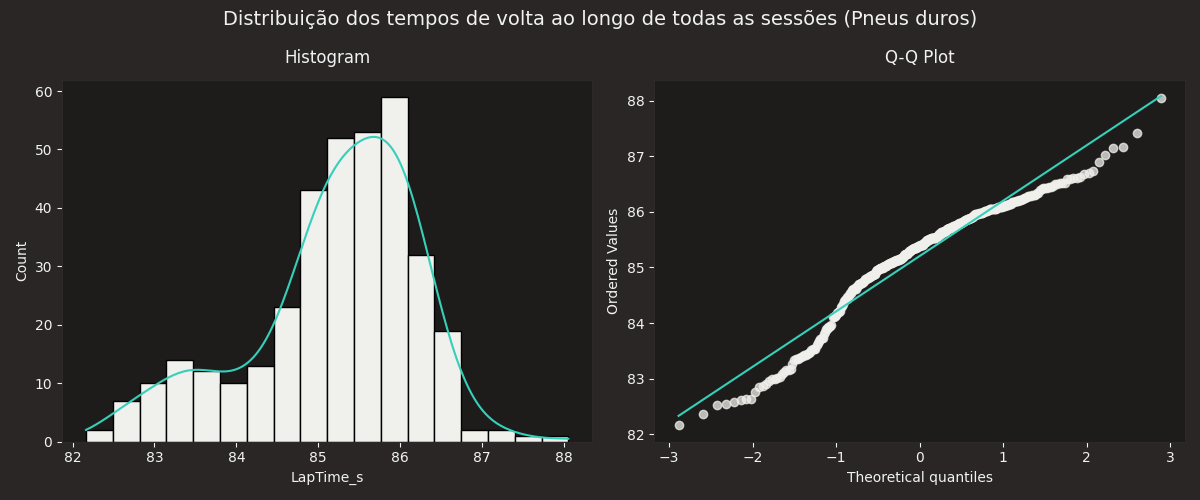

In [17]:
shapiro_wilk_test(hard.LapTime_s, language="pt")
plot_normality_visual_inspection(
    hard.LapTime_s,
    title="Distribuição dos tempos de volta ao longo de todas as sessões (Pneus duros)",
    color=plotting.get_compound_color("hard", session=quali),
)

Contudo, quando se trata de pneus duros, por mais que o teste ainda falhe, a curva se aproxima visualmente muito mais da curva de bell do que para outros compostos. Também nos aprofundaremos nessa distribuição futuramente.

### ⚡ Analisando o tempo de volta em relação às velocidades registradas no primeiro setor intermediário da pista

Como será explicado futuramente neste notebook, a velocidade no primeiro intermédio desse circuito é decisiva para se obter bons tempos de volta. É a parte mais importante do circuito para reduzir tempos de volta.

Test statistic 0.9466
P-Value 0.0000
Os dados NÃO parecem normalmente distribuídos.


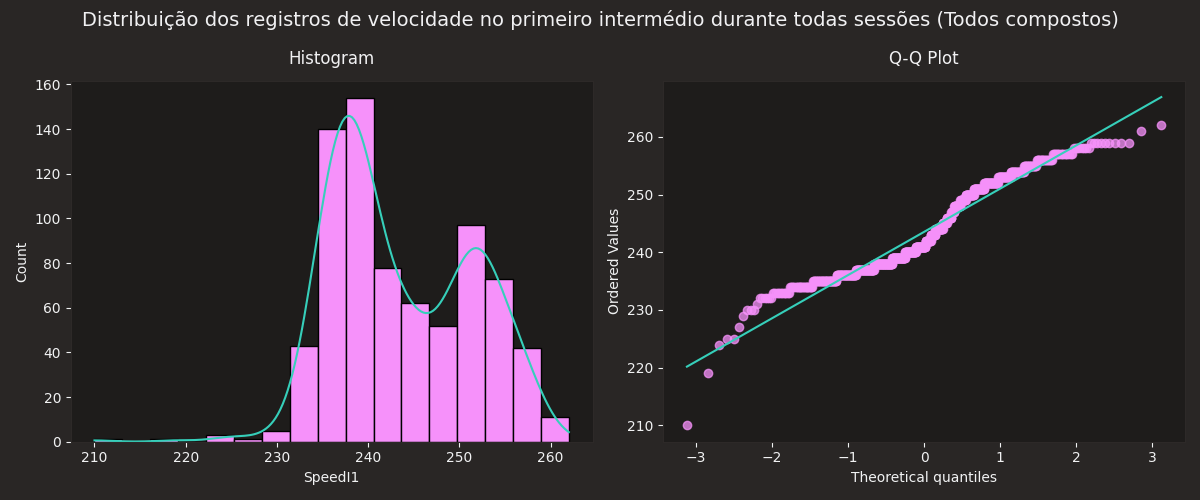

In [18]:
shapiro_wilk_test(all_laps["SpeedI1"], language="pt")
plot_normality_visual_inspection(
    all_laps["SpeedI1"],
    title="Distribuição dos registros de velocidade no primeiro intermédio durante todas sessões (Todos compostos)",
)

As curvas aqui parecem espelhar as tendências dos tempos de volta, mas inversamente.

#### 📈 Com estes valores estão relacionados?

Utilizaremos de scatter plots para visualizar como velocidade e tempos de volta estão relacionados de acordo com o composto do pneu.

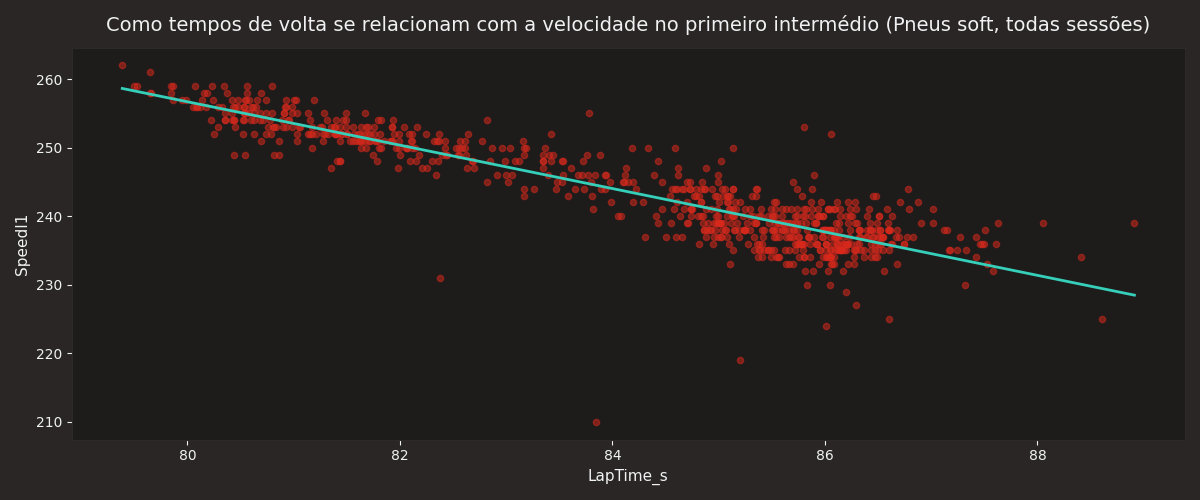

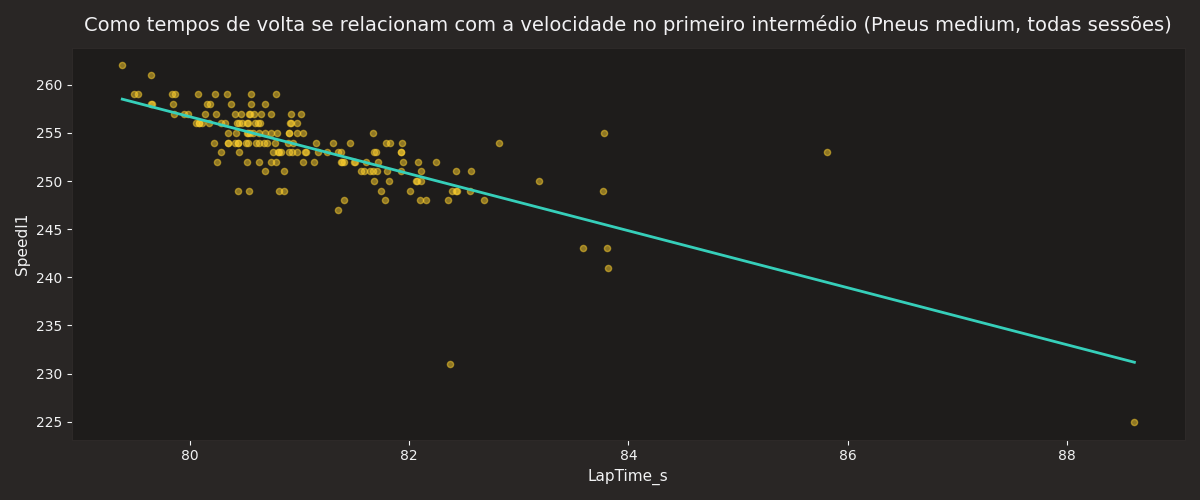

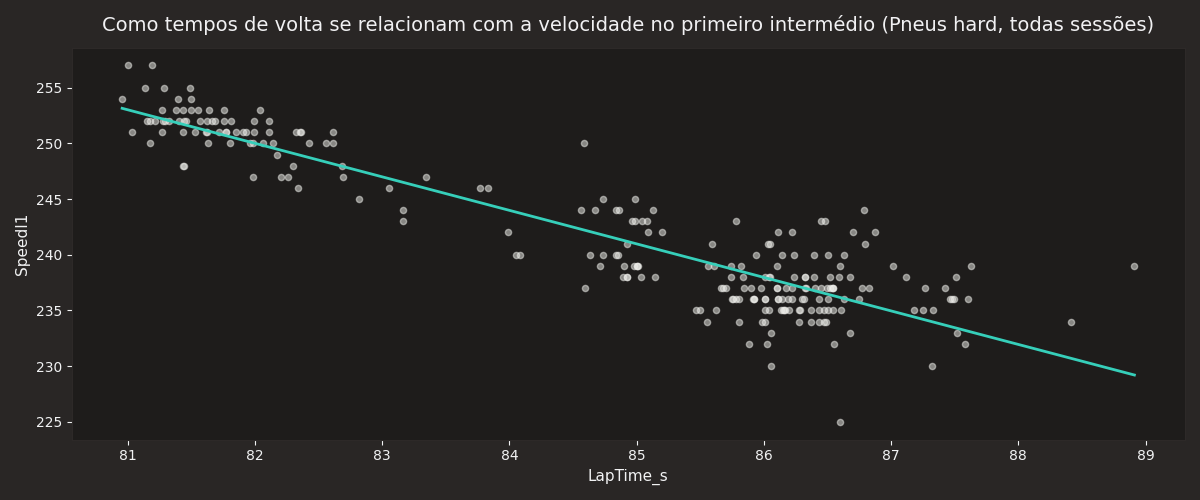

In [19]:
TYRES_CONFIG = ["SOFT", "MEDIUM", "HARD"]

for tyre_config, laps_data in zip(
    TYRES_CONFIG,
    [all_laps, soft, medium, hard],
    strict=False,
):
    plot_scatter(
        laps_data.LapTime_s,
        laps_data.SpeedI1,
        title=f"Como tempos de volta se relacionam com a velocidade no primeiro intermédio (Pneus {tyre_config.lower()}, todas sessões)",
        color=plotting.get_compound_color(tyre_config, quali),
    )

Existe uma alta correlação linear entre as duas variáveis ao analisar o scatter plot visualmente.

## 🛞 Analisando compostos de pneu diferentes

O gerenciamento de pneus é uma das áreas mais cruciais para se obter sucesso na Fórmula 1. Como será explicado em breve, nesse GP em específico, foi uma grande parte do que definiiu as posições finais.

À medida que pilotos completam voltas, quantidade de desgaste do pneu aumenta, fazendo com que os pneus, em tese, perdam aderência, assim aumentando os tempos de volta, sobretudo em circuitos focados em curvas. Contudo, pneus "frios", isto é, fora da temperatura de atuação ideal, também não oferecem boa aderência. Os pneus precisam esquentar na pista.

Dessa forma, a maioria dos compostos possuem uma janela de atuação ótima, balanceando temperatura e desgaste.

### 🟡 Analisando a influência do composto médio no tempo de volta

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


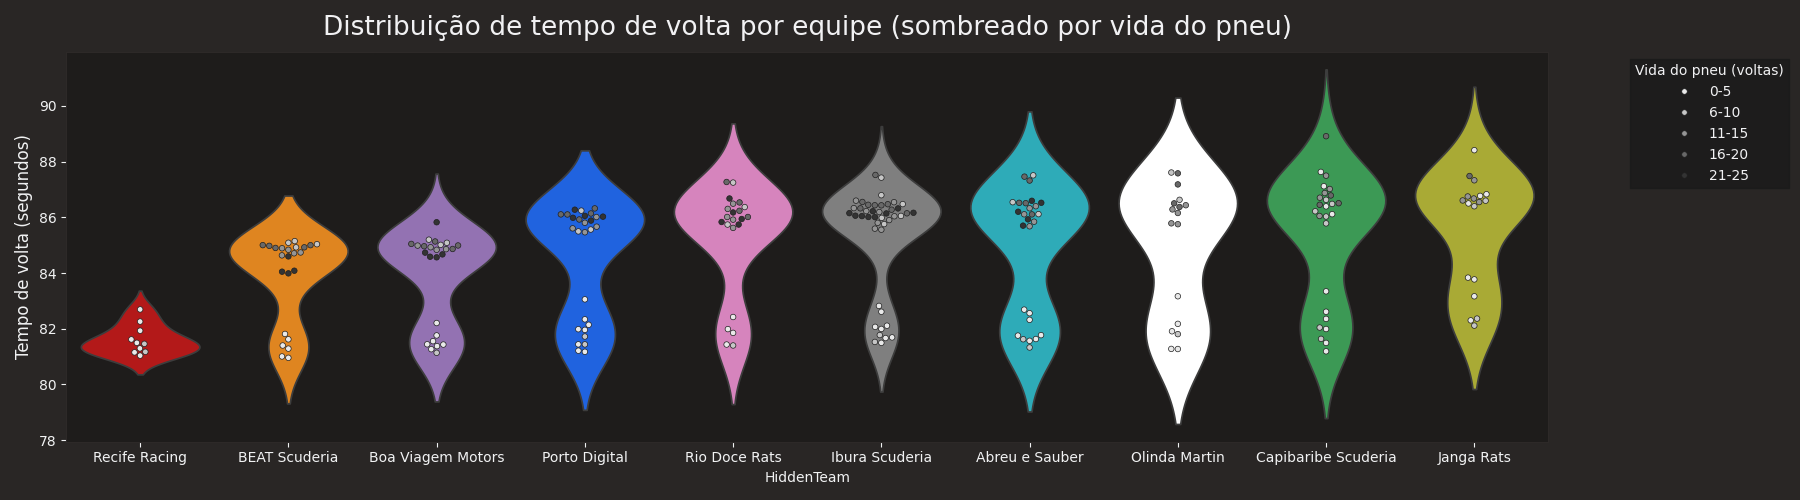

In [ ]:
plot_laptime_distribution_by_team_with_tyre_life(
    medium,
    quali,
    language="pt",
    hide_team=True,
)

É possível perceber que a maiooria dos times segue distribuições similares para compostos médios. Mantenha em mente, entretanto, que essa visualização é limitada para uma corrida, uma vez que agrega dados de todos os tipos diferentes de sessão.

In [ ]:
compare_team_series_to_overall_series(
    mann_whitney_u_test,
    medium,
    TEAM,
    "LapTime_s",
    language="pt",
    hide_team=True,
)

========== Mann-Whitney U ==========
Test statistic 201.0000
P-Value 0.0023
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Red Bull Racing

========== Mann-Whitney U ==========
Test statistic 171.0000
P-Value 0.0040
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Kick Sauber

========== Mann-Whitney U ==========
Test statistic 94.0000
P-Value 0.0002
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Racing Bulls

========== Mann-Whitney U ==========
Test statistic 108.0000
P-Value 0.0063
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Alpine

========== Mann-Whitney U ==========
Test statistic 277.5000
P-Value 0.6599
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Mercedes

========== Mann-Whitney U ==========
Test statistic 117.0000
P-Value 0.0221
NÃO existe diferenca estatisticamente significat

Esse teste é relativamente menos sensível a variância, focando em mudanças de medidas de tendência central, como médias e medianas. Dessa forma, ele ilustra o quão complexo é tentar analisar dados na F1: mesmo dentre a equipes mais rápidas e mais lentas, ao rodar um teste de Mann-Whitney U, ainda não é possível detectar uma diferença de tempos de volta estatisticamente significante, com apenas uma exceção.

In [51]:
compare_team_series_to_overall_series(
    ks_test,
    medium,
    TEAM,
    "LapTime_s",
    language="pt",
    hide_team=True,
)

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.7500
P-Value: 0.0002
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Recife Racing

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6667
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Abreu e Sauber

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.7727
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Rio Doce Rats

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6667
P-Value: 0.0001
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Janga Rats

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.1500
P-Value: 0.8853
NÃO existe diferença estatisticamente signif

Contudo, ao utilizar o teste de Kolmogorov-Smirnov, foi possível identificar diferenças estatisticamente significantes contra o restante do grid, com a notória exceção do terceiro time. Esse teste foca em extrair o máximo de distância vertical entre duas curvas cumulativas, avaliando o quão bem é o fit. Ele é mais sensível para mudanças de variância ou forma geral. Dessa forma, A principal diferença estaticamente significante entre as voltas dos times neste final de semana se concentra na consistência em vez de velocidade média ou mediana. Mantenha isso em mente, à medida que formos analisar os resultados dessa corrida.

#### 🟡 Como esse composto influencia no tempo de volta?

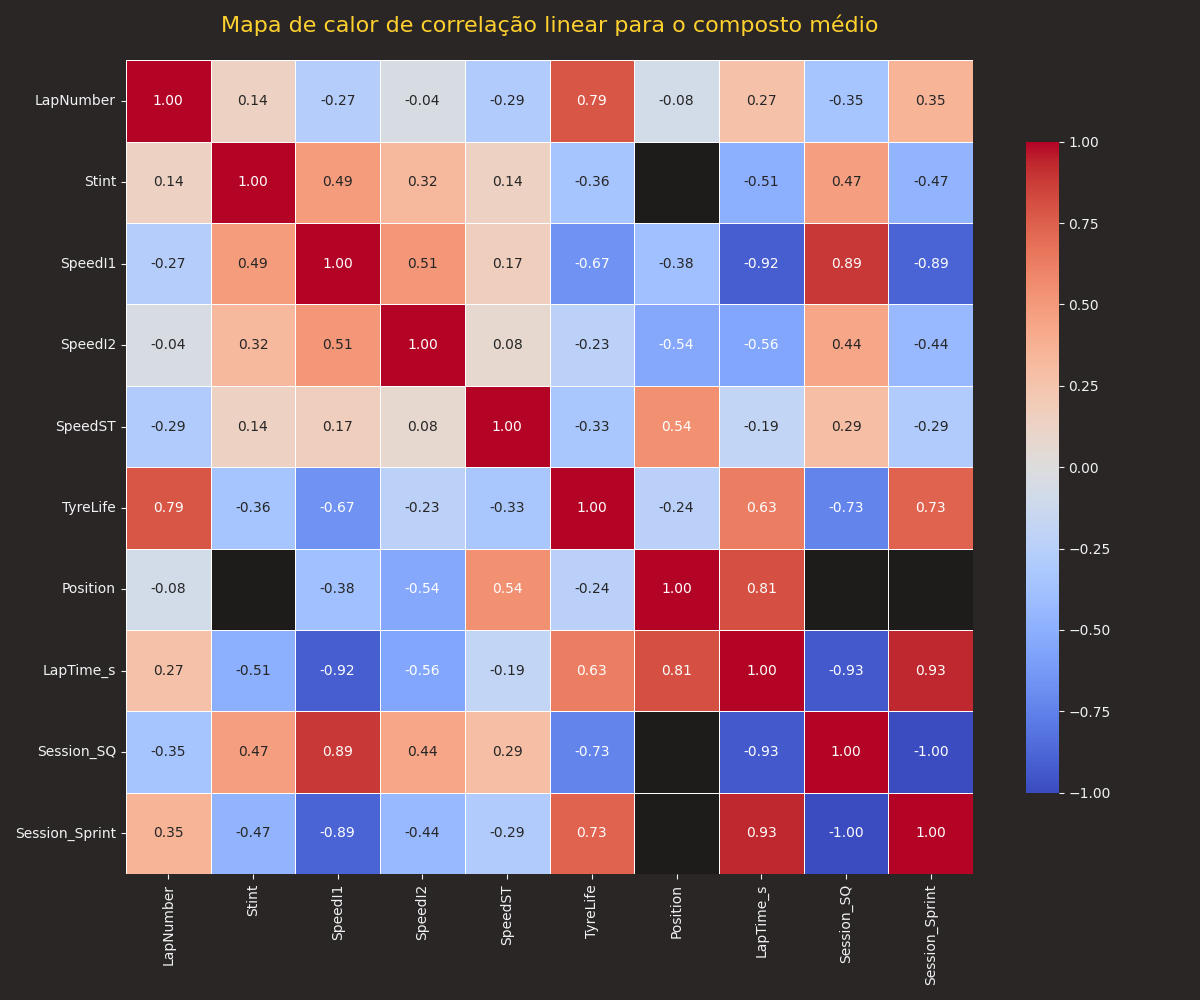


--- Correlations with lap time ---
Session_SQ        -0.93
Session_Sprint     0.93
SpeedI1           -0.92
Position           0.81
TyreLife           0.63
SpeedI2           -0.56
Stint             -0.51
LapNumber          0.27
SpeedST           -0.19
Name: LapTime_s, dtype: object


In [23]:
plot_laptime_correlation_heatmap(
    medium,
    title="Mapa de calor de correlação linear para o composto médio",
    title_color=plotting.get_compound_color("medium", quali),
)

Ao analisar os fatores com maior correlação linear com o tempo de volta usando compostos médios, foi possível detectar que as maiores correlações eram associadas com o tipo de sessão, destacando o quão diferentes voltas podem ser em sessões diferentes.

A velocidade registrada no primeiro setor intermediário foi a característica mais decisiva para extrair bons tempos de volta. Essa velocidade é altamente correlacionada com o desgaste dos pneus (TyreLife), apresentando um valor de -0.67. Isso é esperado, uma vez que a aderência dos pneus é um dos componentes cruciais para se obter alta velocidade.

Como esperado, há uma alta correlação entre tempo de voltas e posição final (0.81).

Finalmnete, a vida dos pneus possui uma correlação direta com o tempo de volta de 0.63 ao utilizar pneus médios, demonstrando seu desgaste de aderência.

Esses dados são cruciais para projetar um plano de corrida e decidir aonde focar na pista.

#### 🟡 Medindo o desgaste dos pneus médios

Agora, vamos usar dados para entender como os pneus se desgastam. Isso é crucial para determinar quando realizar pit stops.

Ao analisar a performance dos pneus, é crucial, conforme ilustado no mapa anterior, separar por tipos de sessão. Ademais, focar mais na tendência do delta dos tempos de volta do que a saída bruta de tempo, uma vez que diferentes sessÕes tendem a apresentar tempos de volta mais curtos (qualificatórias).

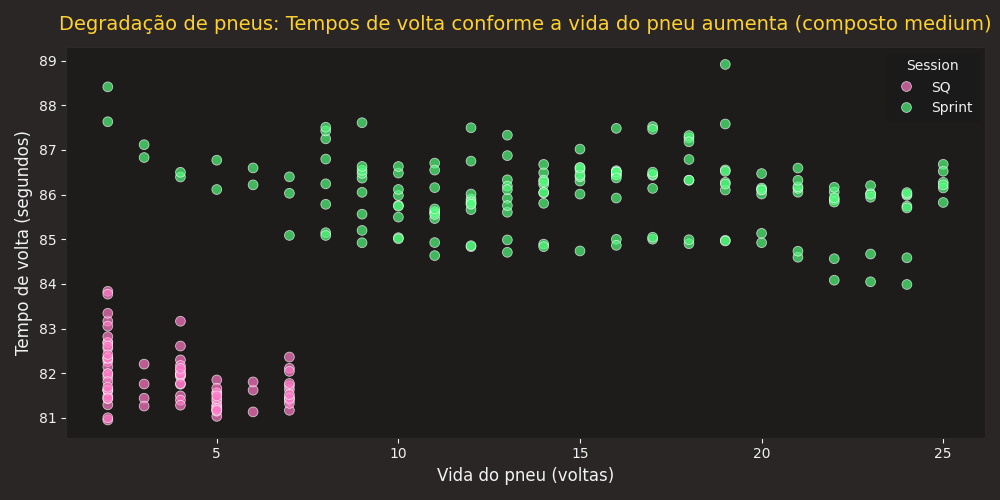

In [24]:
plot_tyre_decay_scatter_plot(
    medium,
    title_color=plotting.get_compound_color("medium", quali),
    language="pt",
)

É posssível perceber, pelos gráficos, que a perda de aderência dos pneus médios não tem sido muito grave, tem sido bastante controlada, apesar de haver uma certa perda de performance. Isso também reflete as estratégias dos pilotos para conservar seus pneus.

In [25]:
mann_whitney_u_test(
    medium[medium.Session_SQ == 1]["LapTime_s"],
    medium[medium.Session_Sprint == 1]["LapTime_s"],
)
print()
ks_test(
    medium[medium.Session_SQ == 1]["LapTime_s"],
    medium[medium.Session_Sprint == 1]["LapTime_s"],
)

========== Mann-Whitney U ==========
Test statistic 0.0000
P-Value 0.0000
There is NOT a statistically significant difference between the series.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
There IS a statistically significant difference between the series.


(np.float64(1.0), np.float64(4.630625161998186e-65))

Mais uma vez, medidas de tendência centrais entre os dois tipos de sessão são similares, enquanto as distribuições em si possuem formatos com diferença estatisticamente significante no que se refere a tempos de volta.

Ter acesso a dados de uma sessão de sprint é muito útil, uma vez que, apesar de mais curta, ainda é uma sessão de corrida! Vamos focar nos dados coletados para essa sessão para tentar estimar o desgaste de pneus em um cenário mais próximo da realidade da corrida.

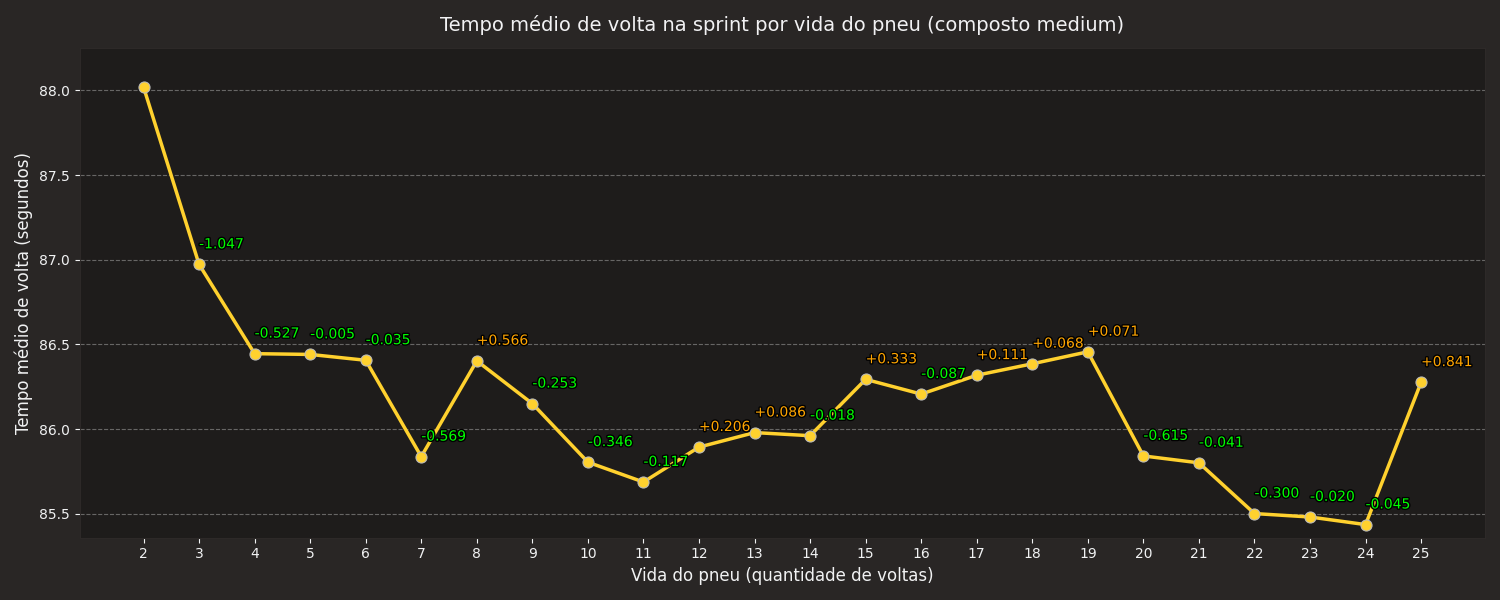

In [26]:
mean_laps_by_life_medium = get_tyre_life_stats(medium, session="Sprint")
plot_average_lap_time_by_tyre_wear(
    mean_laps_by_life_medium,
    "Medium",
    sprint,
    language="pt",
)

Dessa forma, os dados sugerem que a janela ótima de performance para pneus médios se situa no intervalo de 8 a 15 voltas, e então há uma queda de tempo próximo ao final do limite de uso (25), possivelmente devida aos pilotos tentarem extrair o máximo de aderência restante nos pneus antes de trocá-los.

Agora, vamos observar como a queda de performance se dá para o nosso time.

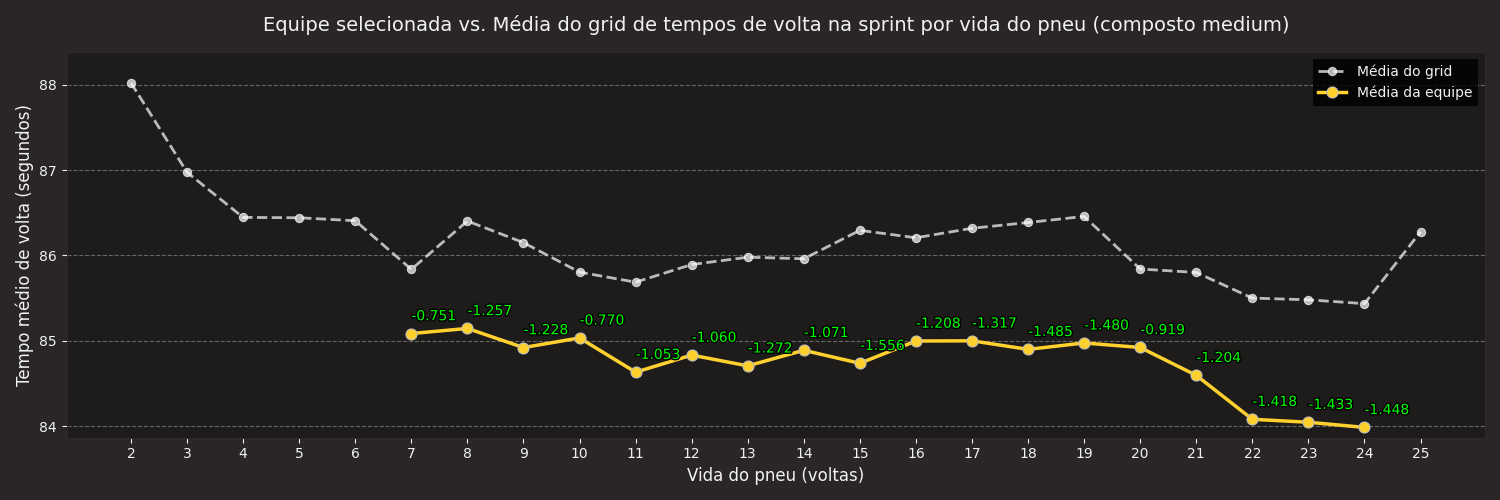

In [27]:
team_mean_laps_by_life_medium = get_tyre_life_stats(
    medium.pick_teams(TEAM),
    session="Sprint",
)
plot_team_vs_grid_tyre_wear(
    mean_laps_by_life_medium,
    team_mean_laps_by_life_medium,
    "MEDIUM",
    sprint,
    language="pt",
)

In [28]:
print(
    f"Média geral do tempo de volta: {mean_laps_by_life_medium.LapTime_s.mean():.3f} "
    f"+/- {mean_laps_by_life_medium.LapTime_s.std():.3f}",
)

Média geral do tempo de volta: 86.167 +/- 0.545


In [29]:
print(
    f"Média do tempo de volta da nossa equipe: {team_mean_laps_by_life_medium.LapTime_s.mean():.3f} "
    f" +/- {team_mean_laps_by_life_medium.LapTime_s.std():.3f}",
)

Média do tempo de volta da nossa equipe: 84.751  +/- 0.359


Não apenas possuímos um tempo médio de volta menor, mas o desvio padrão ao longo da corrida também é menor, demonstrando consistência. Ademais, pelo gráfico, é possível ver que há menos tendências de aumento de tempo de volta ao longo do uso dos pneus. Contudo, os testes ainda trazem os mesmos resultados:

In [30]:
mann_whitney_u_test(
    mean_laps_by_life_medium.LapTime_s,
    team_mean_laps_by_life_medium.LapTime_s,
    language="pt",
)
print()
ks_test(
    mean_laps_by_life_medium.LapTime_s,
    team_mean_laps_by_life_medium.LapTime_s,
    language="pt",
)

========== Mann-Whitney U ==========
Test statistic 432.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 1.0000
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.


(np.float64(1.0), np.float64(5.6545554966993126e-12))

### ⚪ Analisando a influência do composto duro no tempo de volta

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


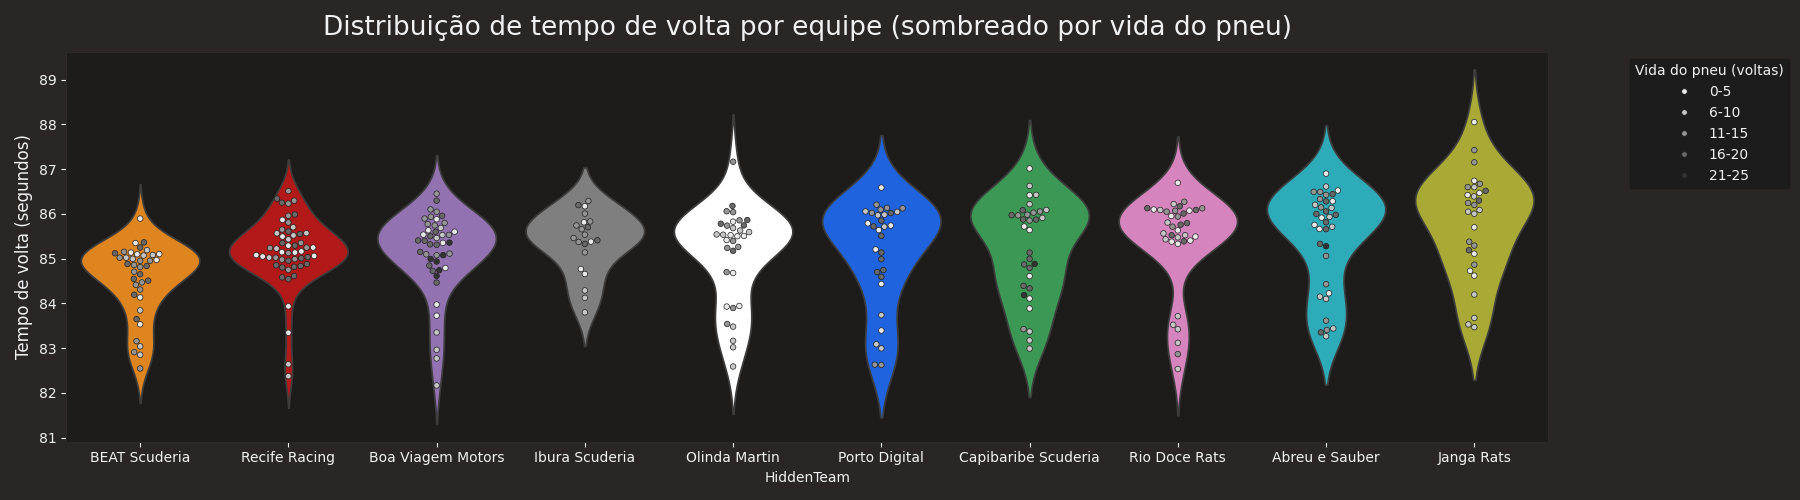

In [31]:
plot_laptime_distribution_by_team_with_tyre_life(
    hard,
    quali,
    language="pt",
    hide_team=True,
)

Enquanto o gráfico para pneus médios se concentrava tanto em tempos de volta menores, com menos desgaste, quanto tempos de volta maiores, com maior desgaste, a concentração para pneus duros se dá majoritariamente em voltas de maior tempo, com alto desgaste.

In [32]:
compare_team_series_to_overall_series(
    mann_whitney_u_test,
    hard,
    TEAM,
    "LapTime_s",
    language="pt",
    hide_team=True,
)

========== Mann-Whitney U ==========
Test statistic 532.5000
P-Value 0.0001
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Recife Racing

========== Mann-Whitney U ==========
Test statistic 309.0000
P-Value 0.0001
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Abreu e Sauber

========== Mann-Whitney U ==========
Test statistic 228.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Rio Doce Rats

========== Mann-Whitney U ==========
Test statistic 212.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Janga Rats

========== Mann-Whitney U ==========
Test statistic 451.0000
P-Value 0.0001
NÃO existe diferenca estatisticamente significativa entre as séries.
Comparando contra Boa Viagem Motors

========== Mann-Whitney U ==========
Test statistic 342.0000
P-Value 0.0007
NÃO existe diferenca estatistica

In [33]:
compare_team_series_to_overall_series(
    ks_test,
    hard,
    TEAM,
    "LapTime_s",
    language="pt",
    hide_team=True,
)

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.3933
P-Value: 0.0012
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Recife Racing

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6374
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Abreu e Sauber

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.7799
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Rio Doce Rats

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.6295
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.
Comparando contra Janga Rats

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.5009
P-Value: 0.0000
EXISTE uma diferença estatisticamente signif

Mais uma vez, os resultados dos testes se repetem.

#### ⚪ Como esse composto influencia no tempo de volta?

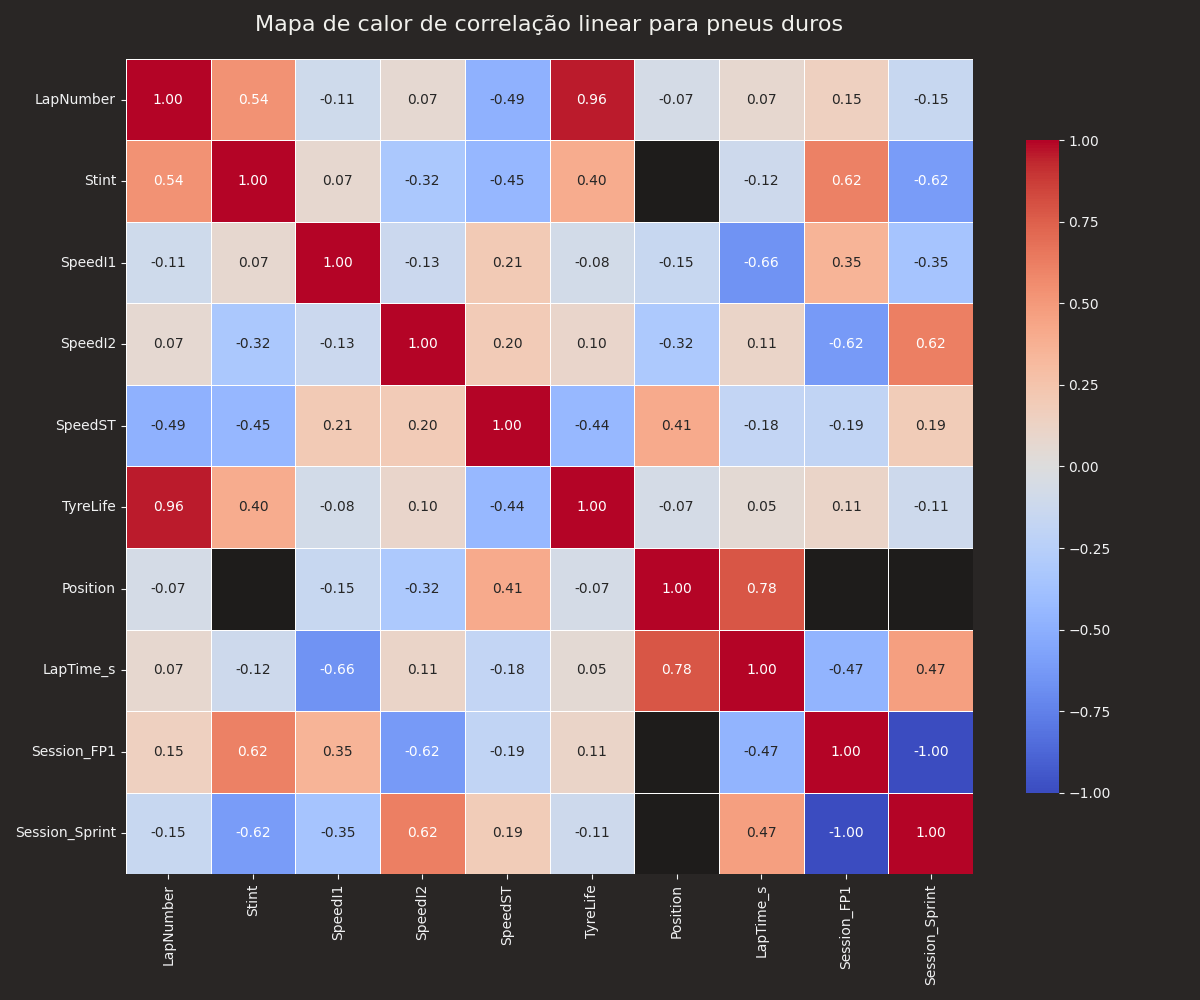


--- Correlations with lap time ---
Position           0.78
SpeedI1           -0.66
Session_FP1       -0.47
Session_Sprint     0.47
SpeedST           -0.18
Stint             -0.12
SpeedI2            0.11
LapNumber          0.07
TyreLife           0.05
Name: LapTime_s, dtype: object


In [34]:
plot_laptime_correlation_heatmap(
    hard,
    title="Mapa de calor de correlação linear para pneus duros",
    title_color=plotting.get_compound_color("hard", quali),
)

Mais uma vez, a velocidade registrada no primeiro setor intermediário ainda é importante, contudo, não tanto quanto para pneus médios. O desgaste dos pneus duros parece não ter nenhuma correlação linear com essa velocidade. Há, contudo, uma correlação negativa com a velocidade nas retas (-0.44). Isto é, quanto maior a vida dos pneus, menor a velocidade.

Porém, vale salientar que para tempos de volta, não é tão importante (-0.18) quanto outros setores.

Não há indicação de nenhum tipo de correlação linear entre o tempo de vida dos pneus duros com o tempo de volta. Vale salientar, contudo, que a velocidade nas retas ainda é uma métrica bastante relevante a ser considerada para oportunidades de ultrapassagem em certos cirtcuitos. Então, é sempre bom manter essa informação em mente ao definir sua estratégia de pneus.

#### ⚪ Medindo o desgaste dos pneus duros

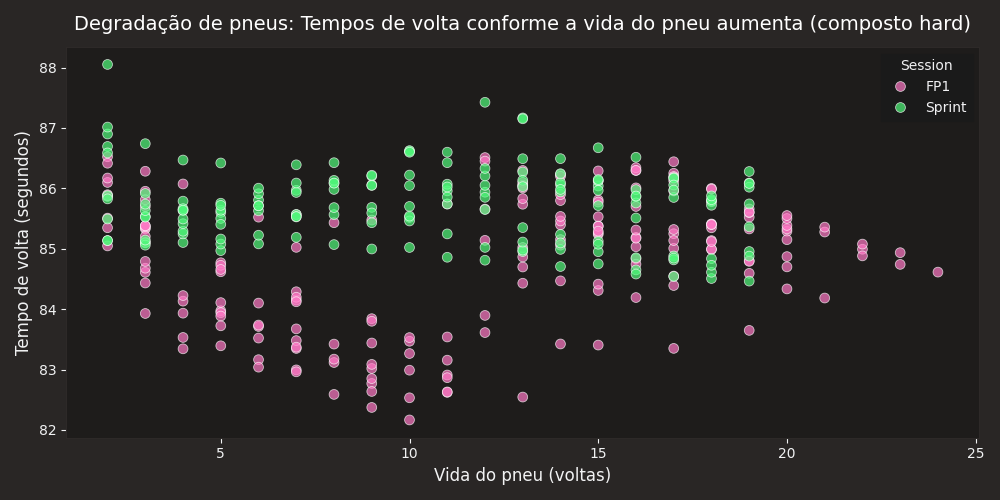

In [35]:
plot_tyre_decay_scatter_plot(hard, language="pt")

Mais uma vez, o gráfico parece estar verticalmetne separado por sessões.

In [36]:
mann_whitney_u_test(
    hard[hard.Session_FP1 == 1]["LapTime_s"],
    hard[hard.Session_Sprint == 1]["LapTime_s"],
    language="pt",
)
print()
ks_test(
    hard[hard.Session_FP1 == 1]["LapTime_s"],
    hard[hard.Session_Sprint == 1]["LapTime_s"],
    language="pt",
)

========== Mann-Whitney U ==========
Test statistic 7686.0000
P-Value 0.0000
NÃO existe diferenca estatisticamente significativa entre as séries.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.4083
P-Value: 0.0000
EXISTE uma diferença estatisticamente significativa entre as séries.


(np.float64(0.4082934609250399), np.float64(1.0332382975397134e-13))

Assim como para o composto médio, as medidas centrais são similares enquanto a forma das distribuições são estatiscametne diferentes.

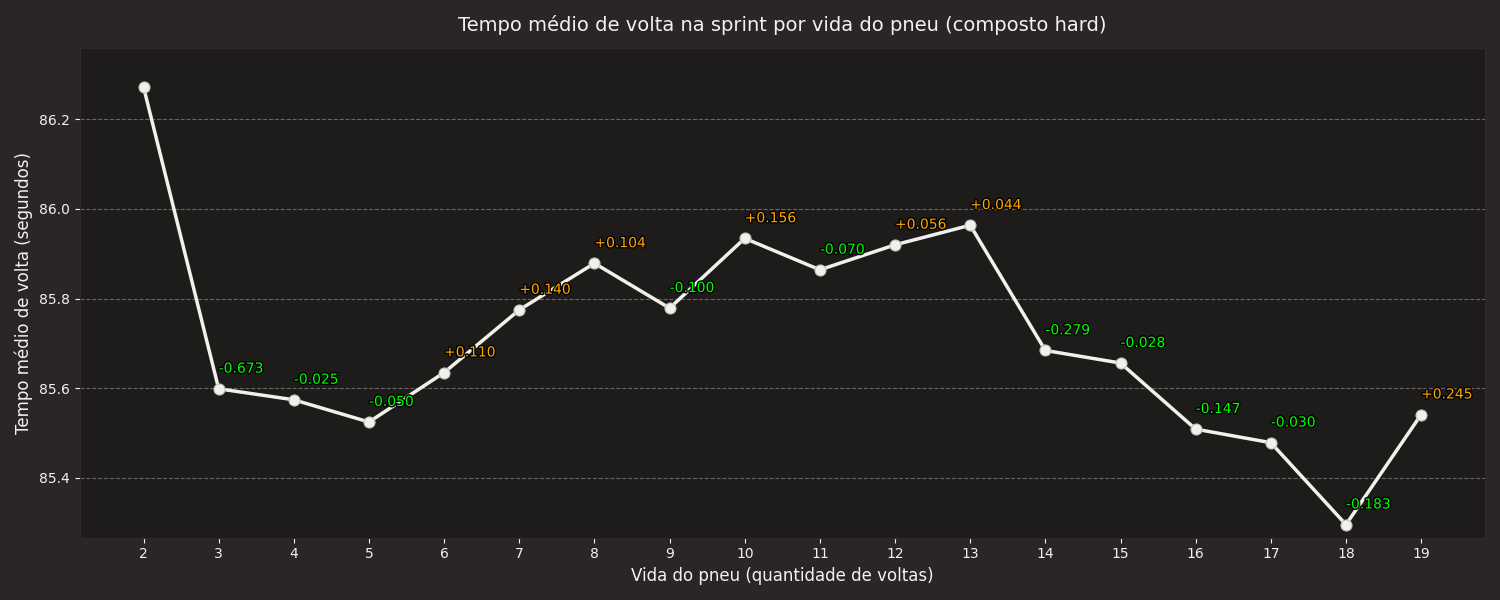

In [37]:
hard_mean_laps_by_life = get_tyre_life_stats(hard, session="Sprint")
plot_average_lap_time_by_tyre_wear(
    hard_mean_laps_by_life,
    "Hard",
    sprint,
    language="pt",
)

Por mais que a performance comece a deteriorar após a quinta volta, os deltas são menores, isso é, há menos variância no tempo de volta. Vamos calcular a diferença entre o desvio padrão dos pneus macios e pneus duros para o grid como um todo.

In [38]:
decrease_of_std = (
    mean_laps_by_life_medium.LapTime_s.std() - hard_mean_laps_by_life.LapTime_s.std()
)
print(
    f"Pneus duros tem uma queda de {decrease_of_std:.3f} em desvio padrão",
    "quando comparados com pneus médios.",
)

Pneus duros tem uma queda de 0.315 em desvio padrão quando comparados com pneus médios.


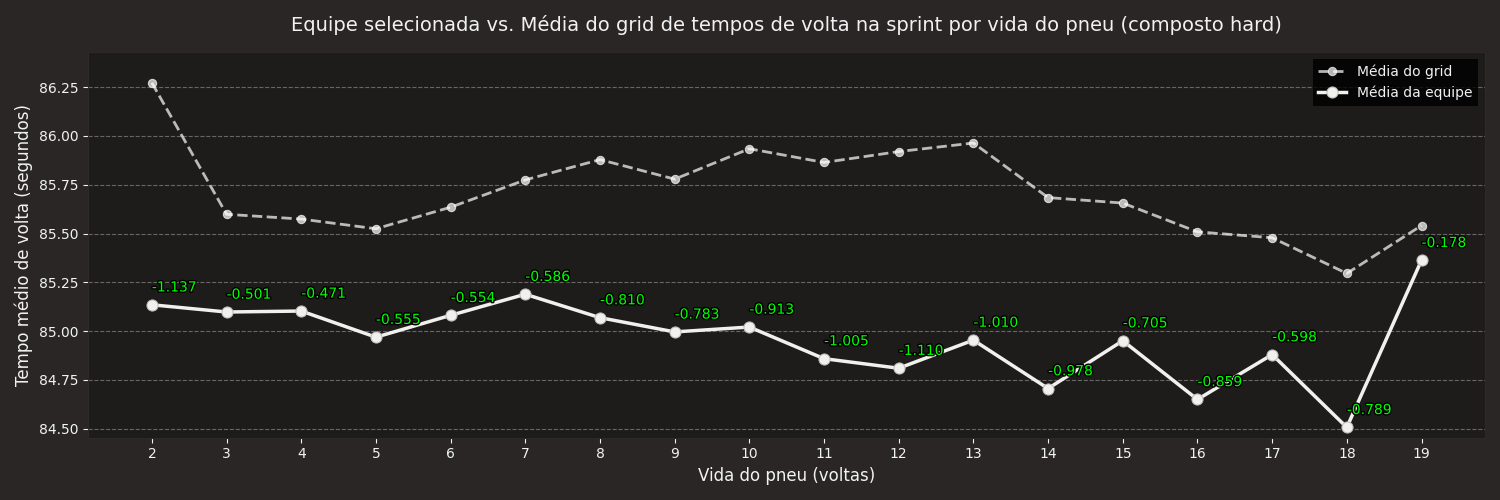

In [39]:
team_mean_laps_by_life_hard = get_tyre_life_stats(
    hard.pick_teams(TEAM),
    session="Sprint",
)
plot_team_vs_grid_tyre_wear(
    hard_mean_laps_by_life,
    team_mean_laps_by_life_hard,
    "HARD",
    sprint,
    language="pt",
)

In [40]:
print(
    f"Tempo de volta médio do grid: {hard_mean_laps_by_life.LapTime_s.mean():.3f} "
    f"+/- {hard_mean_laps_by_life.LapTime_s.std():.3f}",
)

Tempo de volta médio do grid: 85.716 +/- 0.231


In [41]:
print(
    f"Tempo de volta médio da nossa equipe: {team_mean_laps_by_life_hard.LapTime_s.mean():.3f} "
    f" +/- {team_mean_laps_by_life_hard.LapTime_s.std():.3f}",
)

Tempo de volta médio da nossa equipe: 84.963  +/- 0.206


Mais uma vez, ao analizar a performance da nossa equipe em relação grid, é possível observar uma média menor no tempo de volta médio e uma consistência equiparável. Também há menos subidas nos tempos de volta, e uma tendência em direções completamente diferentes da volta 7 até a 12.

In [42]:
mann_whitney_u_test(
    hard_mean_laps_by_life.LapTime_s,
    hard_mean_laps_by_life.LapTime_s,
    language="pt",
)
print()
ks_test(
    team_mean_laps_by_life_hard.LapTime_s,
    team_mean_laps_by_life_hard.LapTime_s,
    language="pt",
)

========== Mann-Whitney U ==========
Test statistic 162.0000
P-Value 1.0000
EXISTE uma diferença estatisticamente significativa entre as séries.

========== Kolomogorov-Smirnov ==========
D-Statistic (Max gap between distributions): 0.0000
P-Value: 1.0000
NÃO existe diferença estatisticamente significativa entre as séries.


(np.float64(0.0), np.float64(1.0))

Os testes também retornam resultados diferentes do que os pneus médios: HÁ uma diferença estatisticamente significante entre as medidas centrais das séries, enquanto a distribuição parece ser a mesma.

### 🔴 Analisando a influência do composto macio no tempo de volta

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:96: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.swarmplot(


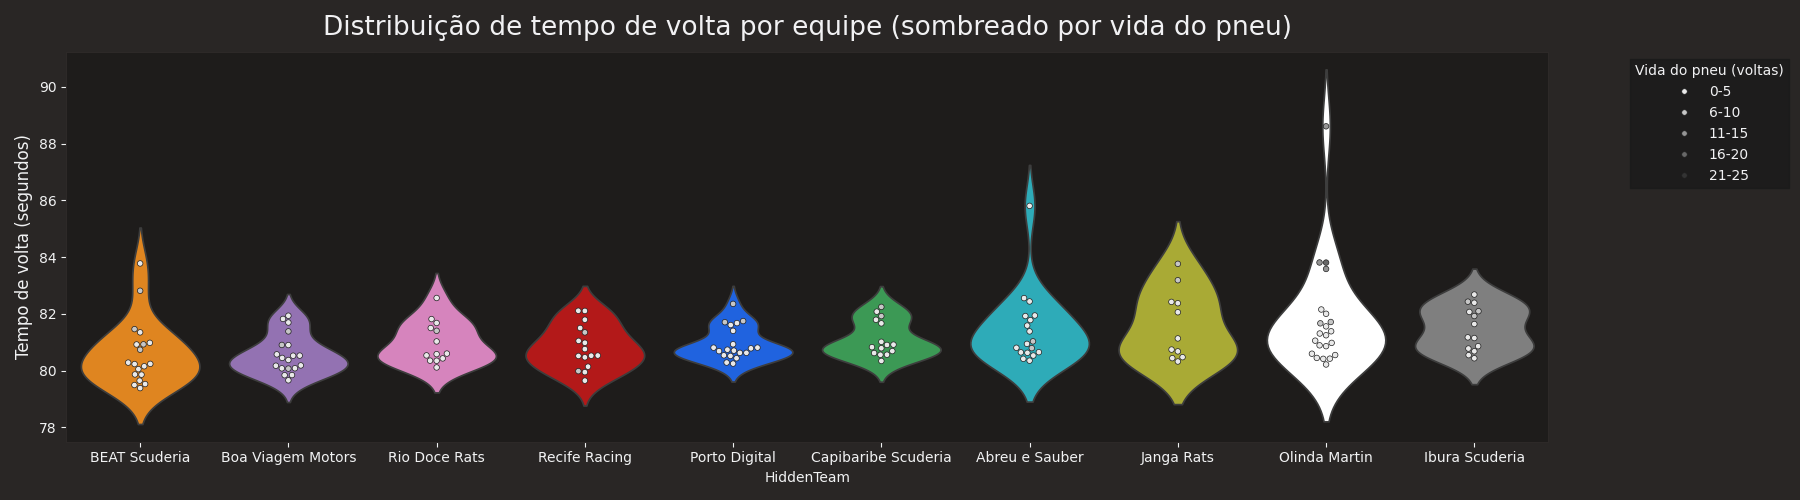

In [ ]:
plot_laptime_distribution_by_team_with_tyre_life(
    soft,
    quali,
    language="pt",
    hide_team=True,
)

Enquanto o gráfico para pneus duros estava concentrado em pneus mais desgastados com maior tempo de volta, e os médios tinham duas concentrações, os macios se concentram em pneus com pouco tempo de vida, para tempos de volta curtos.

Devido ao baixo número de dados referentes a pneus macios macios, não iremos fazer testes de hipótese, uma vez que perdem precisão com uma quantidade menor de dados.

#### 🔴 Como esse composto influencia no tempo de volta?

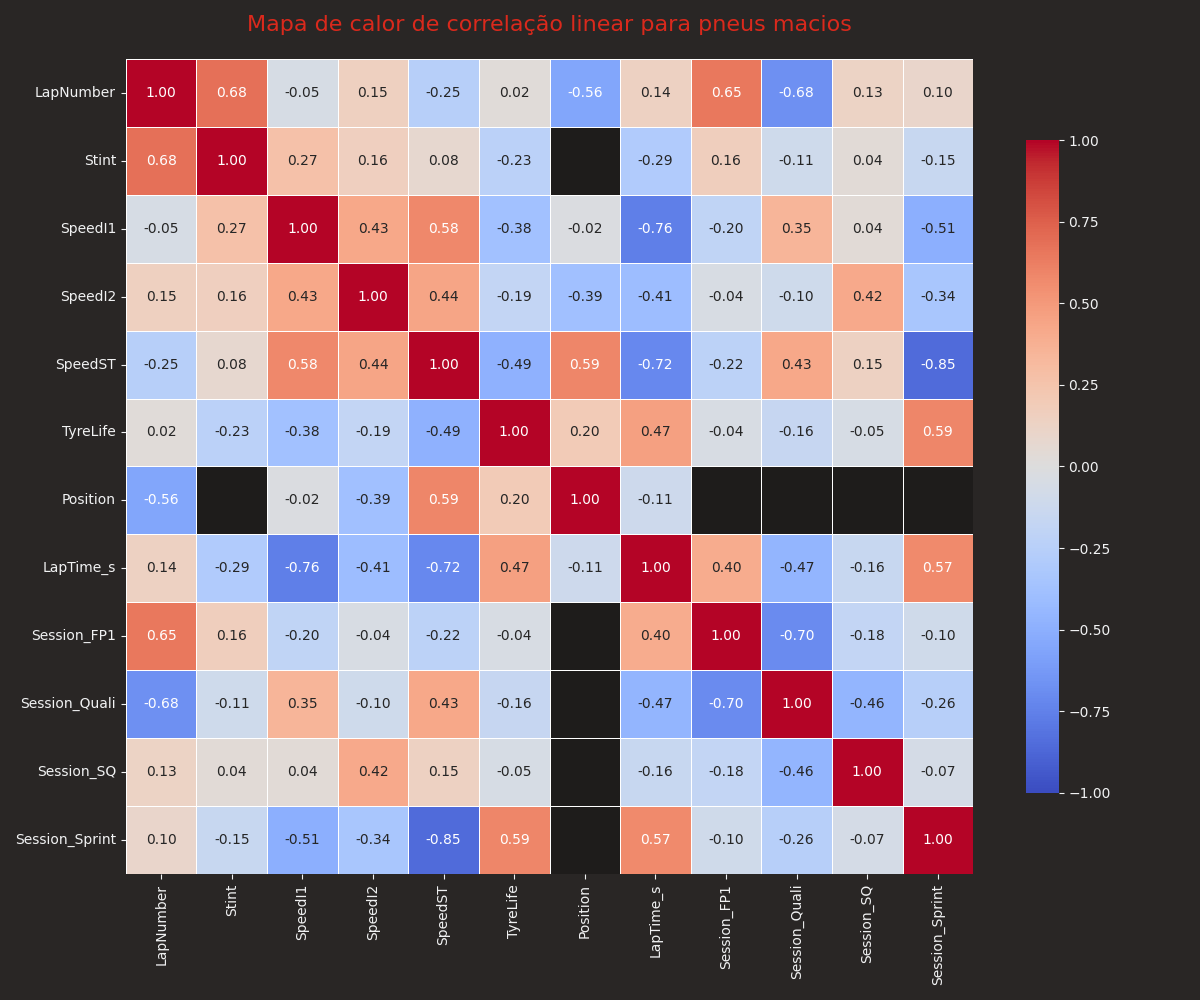


--- Correlations with lap time ---
SpeedI1           -0.76
SpeedST           -0.72
Session_Sprint     0.57
Session_Quali     -0.47
TyreLife           0.47
SpeedI2           -0.41
Session_FP1        0.40
Stint             -0.29
Session_SQ        -0.16
LapNumber          0.14
Position          -0.11
Name: LapTime_s, dtype: object


In [44]:
plot_laptime_correlation_heatmap(
    soft,
    title="Mapa de calor de correlação linear para pneus macios",
    title_color=plotting.get_compound_color("soft", quali),
)

Velocidade registrada no primeiro setor intermediário da pista, mais uma vez, possuiu alta correlação com tempos de volta nos pneus macios, e dessa vez, a velocidade em linhas retas também teve uma correlação similar.

Também há uma correlação negativa moderada entre o desgaste dos pneus e ambas as métricas anteriores (-0.49 e -0.38).

Também há uma correlação linear direta entre maior desgaste dos pneus e aumento nos tempos de volta.

#### 🔴 Medindo o desgaste dos pneus macios

c:\Users\Vitor\cesar-beat-f1-workshop\src\plots\tyres.py:155: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 5))


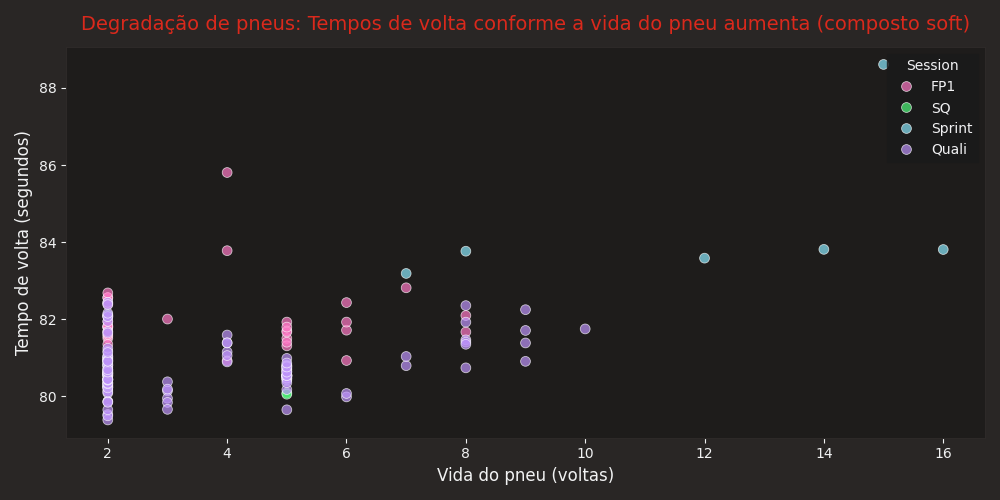

In [45]:
plot_tyre_decay_scatter_plot(
    soft,
    title_color=plotting.get_compound_color("soft", quali),
    language="pt",
)

O gráfico de degradação dos pneus é mais espaçado, e tempos a partir da volta 6 já aparentam haver grande incremento.

Pneus macios também foram usados em todas as sessões deste final de semana.

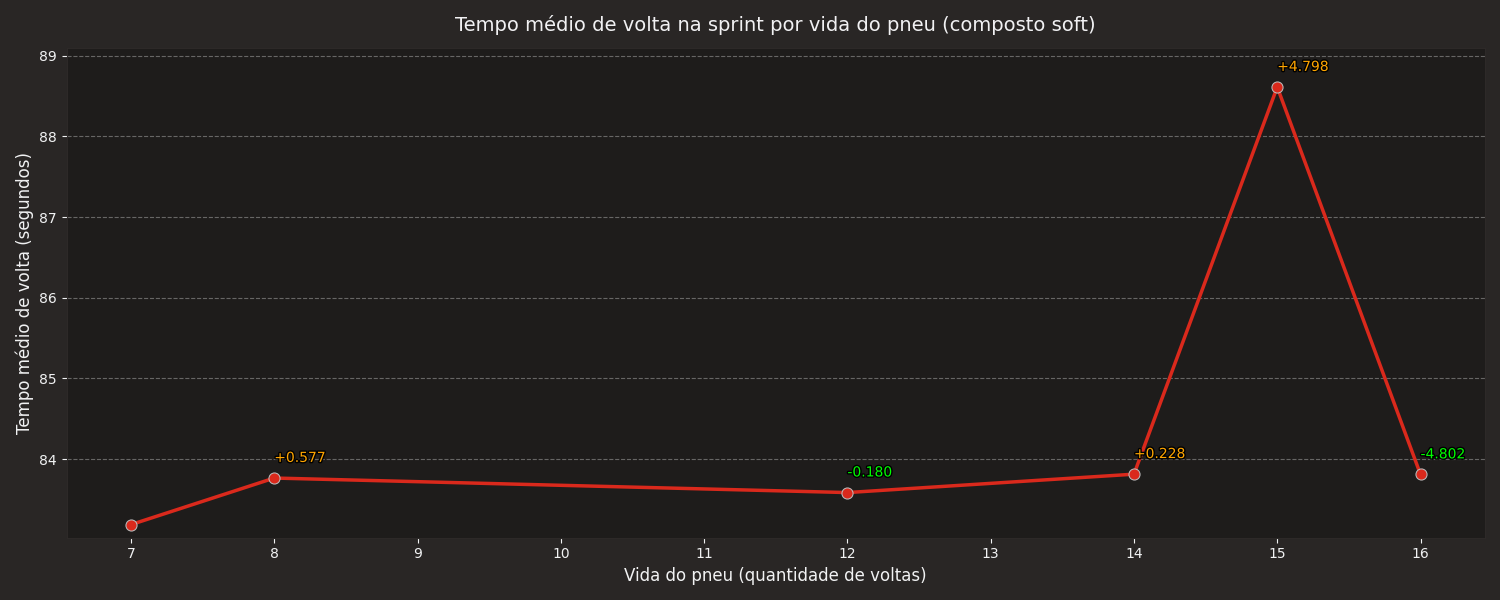

In [46]:
mean_laps_by_life_soft = get_tyre_life_stats(soft, session="Sprint")
plot_average_lap_time_by_tyre_wear(
    mean_laps_by_life_soft,
    "Soft",
    sprint,
    language="pt",
)

Esse gráfico demonstra uma grande variância e grandes quedas na performance dos peneus, entretanto, há apenas 5 data points para pneus macios na sessão de sprint. Vamos incluir outras sessões na análise.

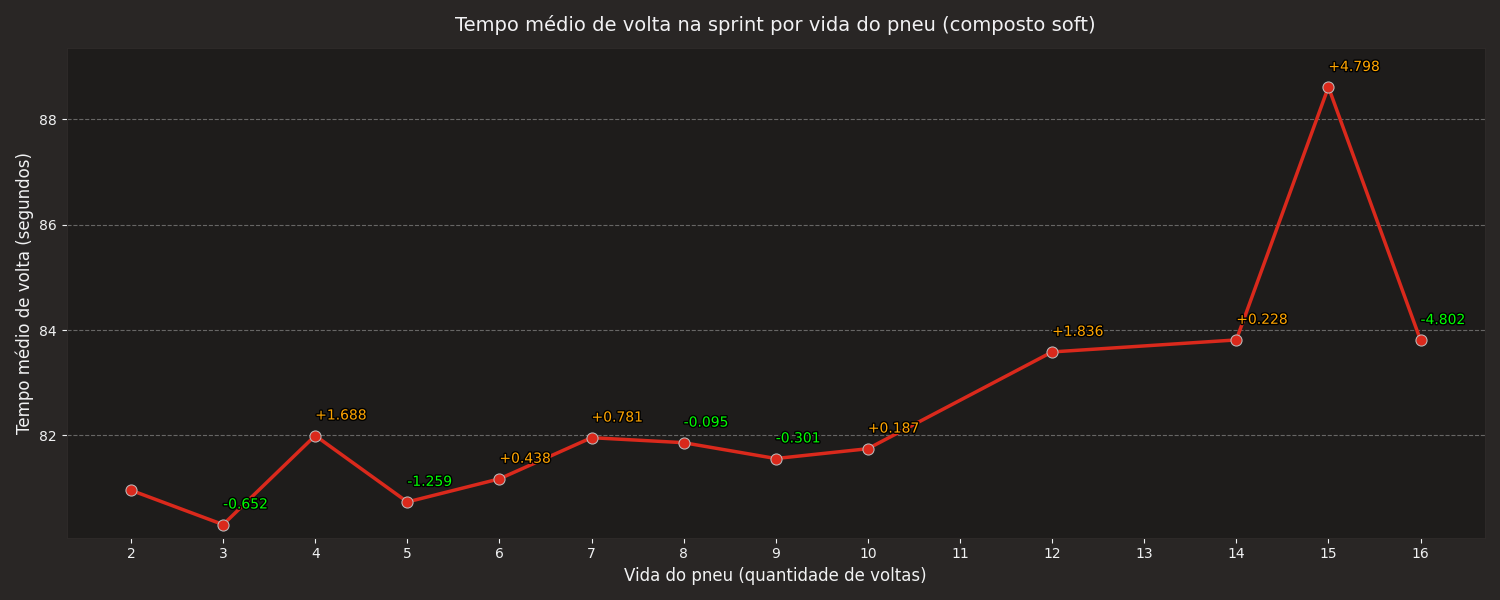

In [47]:
mean_laps_by_life_soft_all_sessions = get_tyre_life_stats(soft)
plot_average_lap_time_by_tyre_wear(
    mean_laps_by_life_soft_all_sessions,
    "Soft",
    sprint,
    language="pt",
)

Esse gráfico ilustra grandes quedas de performance, que parecem se agravar a partir da volta 10. Os intervalos são bem mais agressivos que os outros compostos, variando numa ordem de segundos.

Perceba que enquanto o desvio padrão para outros compostos é medido em milissegundos, para pneus macios, é medido em segundos!

In [48]:
print(
    f"Hard: {hard_mean_laps_by_life.LapTime_s.std():.3f}\n"
    f"Medium: {mean_laps_by_life_medium.LapTime_s.std():.3f}\n",
    f"Soft: {mean_laps_by_life_soft.LapTime_s.std():.3f}",
)

Hard: 0.231
Medium: 0.545
 Soft: 2.046


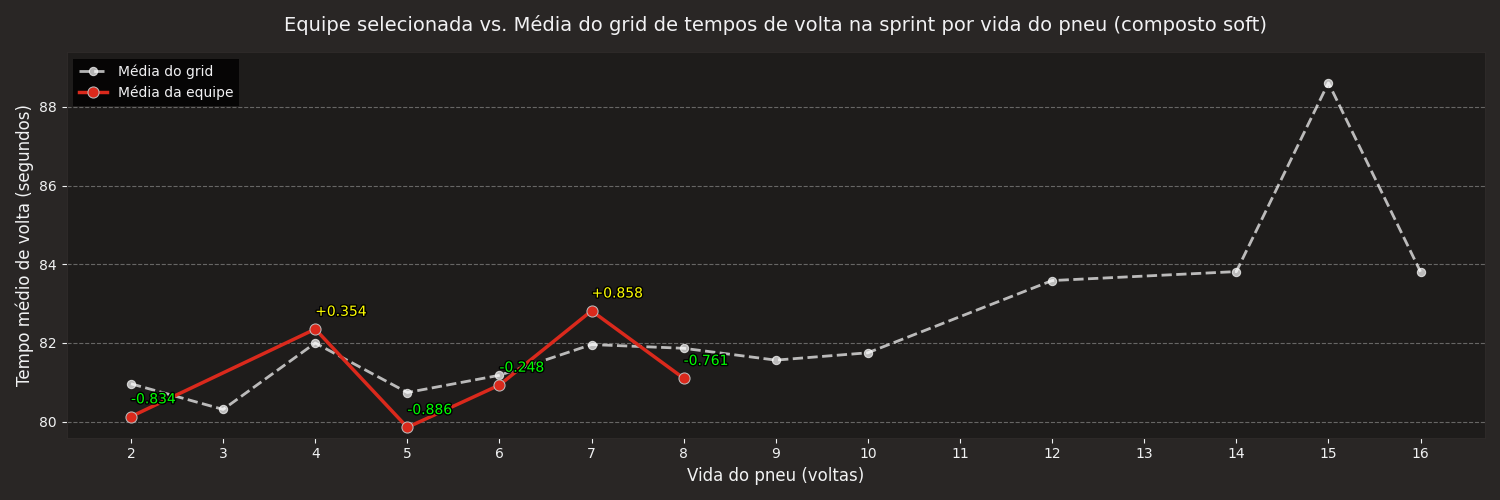

In [49]:
team_mean_laps_by_life_soft = get_tyre_life_stats(soft.pick_teams(TEAM))
plot_team_vs_grid_tyre_wear(
    mean_laps_by_life_soft_all_sessions,
    team_mean_laps_by_life_soft,
    "SOFT",
    sprint,
    language="pt",
)

Adicionalmente, a performance da nossa equipe em pneus macios é visualmente consistente com os outros times, diferentemente dos pneus médios e duros.

## 💡 Resumo e conclusões

### 🕒 Distribuição dos tempos de volta

Os tempos de volta de todos os compostos não são normalmente distribuídos, de acordo com o teste de hipótese de Shapiro-Wilk. Isso é um comportamento esperado em automobilismo. Dessa forma, testes não paramétricos (Mann-Whitney U e Kolmogorov-Smirnov) tiveram de ser usados ao longo da análise.

### ⚡️ Métricas de velocidade

**A velocidade no primeiro setor intermediário (SpeedI1)** foi identificada como a métrica mais imporatante na pista, significantemente correlacionada com o tempo de volta independentemente do composto usado. Como esperado, na inspeção visual, reflete inversamente as distribuições de tempo.

### 🛞 Análise dos compostos de pneu

🟡 Pneus médios
- Janela ótima de performance: **8–15 voltas**.
- Maiores correlacṍes lineares com o tempo de volta: o tipo de sessão (-0.93/+0.93), SpeedI1 (-0.92), posição (0.81) e vida dos pneus (0.63).
- O maior diferencial estatisticamente significante entre os times nesse composo é a consistência (forma de distruição), em vez de ritmo bruto (mediana/média) - a maioria dos times possuem tendências centrais muito similares.
- Nossa equipe nos pneus médios: tempo de volta médio de 84.75s ± 0.36s vs. restante do grid em 86.17s ± 0.55s — somos mais rápidos e consistentes.
- Mantenha em mente que o SpeedI1 possui a maior correlação (-0.72) com os tempos de volta nesse circuito, conforme analisado em corridas anteriores. Isso pode ser maximizado ao usar pneus médios (-0.92).

⚪ Pneus duros
- Janela ótima de performance: o intervalo do tempo de volta não varia muito, mas a tendência do grid é de performance que diminui lentamente após a volta 5, enquanto a da nossa equipe é de performance lentamente melhorada até a volta 14.
- Menor desgaste de pneus: a correlação entre o tempo de volta com a vida dos pneus é de 0.05.
- SpeedI1 continua importante (-0.66).
- Pneus duros possuem **0.315s a menos de desvio padrão** comparados a pneus médios — degradação mais previsível.
- Nossa equipe no composto duro: 84.96s ± 0.21s vs. grid's 85.72s ± 0.23s — **consistentemente mais rápido**, com uma tendência diferente (favorável) entre as voltas 7–12.

🔴 Pneus macios
- Performance concentrada nas primeiras voltas, rapidamente se deteriorando - primariamente um composto para qualificatórias.
- A performance se degrada de forma íngreme a partir da volta 10, com um desvio padrão de 2.17s (vs. 0.54s para médios e 0.23s para duros) - altamente variável, com rápida perda de performance.
- Quanto ao nosso time, nossa performance nesse composto é equiparada ao restante do grid, sem vantagens, diferentemente dos outros compostos.

### 🏁 Insights gerais de estratégia

1. O Setor 1 (Primeira Intermediária) é o trecho mais crítico do circuito — as equipes devem focar a configuração do carro e o estilo de pilotagem em maximizar a velocidade através do primeiro setor intermediário.
2. Os pneus médios são o ponto de convergência — nossa equipe tem uma clara vantagem de ritmo e consistência com eles, tornando-os o composto preferido para a corrida.
3. Os pneus duros oferecem estabilidade para stints longos — eles apresentam uma menor variação de degradação, e nossa equipe também leva vantagem com este composto.
4. Os pneus macios devem ser usados com moderação na corrida — a alta variação de degradação e a ausência de uma vantagem clara fazem deles um risco em stints (sequências de voltas) mais longos.
5. A consistência em vez do ritmo bruto é o principal fator de diferenciação nos tempos de volta — o teste KS confirmou que o formato da distribuição (variância) diferencia mais as equipes do que as medianas dos seus tempos de volta.